In [84]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt


window_size = 500_000
insulation_df_wtnou = pd.read_csv('/home/carlos/Clone/ggner-3d/data/insulation/insulation_WTnoUV_10000bp.csv')

In [85]:
boundaries = insulation_df_wtnou.loc[insulation_df_wtnou[f'boundary_strength_{window_size}']>0][['chrom', 'start', 'end', f'boundary_strength_{window_size}', f'is_boundary_{window_size}']]

In [86]:
strong_boundaries = boundaries[boundaries[f'is_boundary_{window_size}'] 
                               == True].reset_index(drop=True)
geneids = [f'{chr}:{start}-{end}' for chr, start, end in zip(strong_boundaries['chrom'], strong_boundaries['start'], strong_boundaries['end'])]

In [87]:
strong_boundaries['Geneid'] = geneids

In [88]:
deseq_results = pd.read_csv('/home/carlos/Clone/ggner-3d/src/r_scripts/deseq/DESeq2_WTnoUV_vs_XPCnoUV_all_results.csv')
deseq_results.rename(columns={'Chr': 'chrom', 'Start': 'start', 'End': 'end'}, inplace=True)

deseq_results['-log10_padj'] = -np.log10(deseq_results['padj'])


In [89]:
boundaries = boundaries.copy()
deseq_results = deseq_results.copy()

boundaries["feature_id"] = (
    boundaries["chrom"].astype(str)
    + ":"
    + boundaries["start"].astype(str)
    + "-"
    + boundaries["end"].astype(str)
)

merged = boundaries.merge(
    deseq_results,
    on="feature_id",
    how="left",   # use "inner" if you only want matched rows
    suffixes=("_boundary", "_deseq"),
)

In [90]:
merged_filtered = merged[merged['is_boundary_500000'] == True]

Text(0.5, 1.0, 'Volcano Plot of DESeq2 Results for Strong Boundaries')

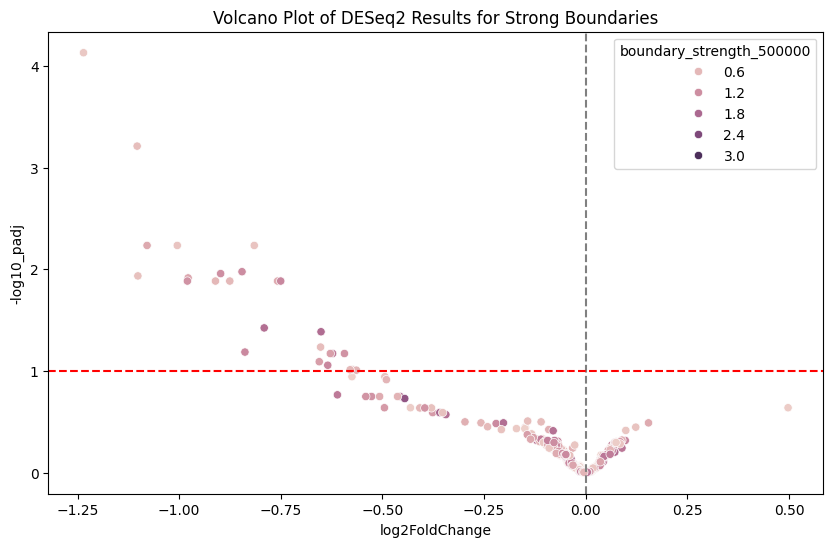

In [96]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=merged_filtered, x='log2FoldChange', y='-log10_padj', hue='boundary_strength_500000' ,ax=ax)
# add vline and hline for significance thresholds
ax.axvline(x=0, color='grey', linestyle='--')
ax.axhline(y=-np.log10(0.1), color='red', linestyle='--')
ax.set_title('Volcano Plot of DESeq2 Results for Strong Boundaries')

In [92]:
featureCounts = pd.read_csv('/home/carlos/Clone/ggner-3d/src/r_scripts/deseq/boundaries_wtnouv_all.featureCounts.txt', sep='\t', comment='#')

In [93]:
featureCounts_strong_boundaries = featureCounts[featureCounts['Geneid'].isin(strong_boundaries['Geneid'])]

In [94]:
featureCounts_strong_boundaries.to_csv('/home/carlos/Clone/ggner-3d/src/r_scripts/deseq/featureCounts_strong_boundaries.txt', sep='\t', index=False)